In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # anaconda mkl + pip torch dll clash on windows - see train.ipynb

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


In [2]:
# test.ipynb - real acquired iqt lr -> frozen preprocessing -> frozen trained model ->
# enhanced output, compared against the respiratory-phase-paired real acquired hr. this
# is the real-data test, distinct from evaluate.ipynb's synthetic tv8 domain. the training
# pipeline is frozen - no training, no model selection, no tuning against this real data.
# real hr is used only as the evaluation reference, never fed into the model.

CROP_SIZE = 80
CHANNELS = [8, 16, 32, 64]  # frozen architecture - must match the checkpoint being loaded

candidate_output_dirs = [Path.cwd(), Path.cwd() / "Development"]
OUTPUT_DIR = next((d / "Outputs" for d in candidate_output_dirs if (d / "Outputs").exists()), Path.cwd() / "Outputs")

REAL_PAIRS_PATH = OUTPUT_DIR / "iqt_real_pairs_export.npz"
CHECKPOINT_PATH = OUTPUT_DIR / "spatial_baseline_final.pt"
assert REAL_PAIRS_PATH.exists(), f"real pairs export not found at {REAL_PAIRS_PATH.resolve()} - run preprocessing.ipynb's export step first"
assert CHECKPOINT_PATH.exists(), f"frozen checkpoint not found at {CHECKPOINT_PATH.resolve()} - run train.ipynb's RUN_FINAL step first"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("checkpoint path:", CHECKPOINT_PATH)
print("architecture (CHANNELS):", CHANNELS)
print("real pairs export:", REAL_PAIRS_PATH)


checkpoint path: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt
architecture (CHANNELS): [8, 16, 32, 64]
real pairs export: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\iqt_real_pairs_export.npz


In [3]:
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("no gpu available, running on cpu")


device: cpu
no gpu available, running on cpu


In [4]:
real_data = np.load(REAL_PAIRS_PATH, allow_pickle=True)
print("export arrays:", list(real_data.files))

real_lr_all = real_data["lr_frames"]
real_hr_all = real_data["hr_frames"]
real_slice = real_data["slice"]
real_lr_dyn = real_data["lr_dynamic"]
real_hr_dyn = real_data["hr_dynamic"]
real_phase_bin = real_data["phase_bin"]
real_direction = real_data["direction"]
real_fallback = real_data["fallback"]
real_phase_dist = real_data["phase_pairing_distance"]
real_dice = real_data["mean_dice"]
real_included = real_data["included"]
real_exclusion_reason = real_data["exclusion_reason"]

assert real_lr_all.shape[1:] == (CROP_SIZE, CROP_SIZE)
assert real_hr_all.shape[1:] == (CROP_SIZE, CROP_SIZE)

n_candidate = len(real_included)
n_included = int(real_included.sum())
n_excluded = n_candidate - n_included
print(f"\ncandidate pairs: {n_candidate}   included: {n_included}   excluded: {n_excluded}")
if n_excluded:
    print("exclusion reasons:")
    print(pd.Series(real_exclusion_reason[~real_included]).value_counts())


export arrays: ['lr_frames', 'hr_frames', 'slice', 'lr_dynamic', 'hr_dynamic', 'echo', 'phase_bin', 'direction', 'fallback', 'phase_pairing_distance', 'mean_dice', 'n_slices_scored', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'landmark_diaphragm_y', 'landmark_mid_x', 'lr_native_size', 'hr_native_size', 'included', 'exclusion_reason']

candidate pairs: 180   included: 180   excluded: 0


In [5]:
# real lr, never degraded or resized further - the export already applied the frozen
# crop convention (per_subject_crop["IQT_HR"]'s window, shared identically between lr and
# hr - see preprocessing.ipynb step 9). only normalisation happens here.
inc = real_included
lr_inc, hr_inc = real_lr_all[inc], real_hr_all[inc]
slice_inc = real_slice[inc]


def normalise(img, lo, hi):
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


# percentile scale derived from the REAL LR series only, grouped by slice (there is one
# real iqt participant, not a subject/slice grid like the tv export) - matches train.ipynb's
# established principle exactly ("at inference on the real iqt data only the lr acquisition
# exists, so hr-derived statistics wouldn't be computable there"), just fed by real lr
# instead of a synthetically degraded one. the same (lo, hi) is applied to both lr and hr.
real_percentile_scale = {}
for s in sorted(set(slice_inc.tolist())):
    series = lr_inc[slice_inc == s]
    real_percentile_scale[s] = tuple(np.percentile(series, [1, 99]))
print(f"percentile scaling (from real lr) computed for {len(real_percentile_scale)} slices")


percentile scaling (from real lr) computed for 6 slices


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    # unchanged from train.ipynb - 80x80 input, four downsampling levels
    def __init__(self, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.pool = nn.MaxPool2d(2)
        self.enc1 = ConvBlock(1, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c4)
        self.up4 = nn.ConvTranspose2d(c4, c4, 2, stride=2)
        self.dec4 = ConvBlock(c4 + c4, c3)
        self.up3 = nn.ConvTranspose2d(c3, c3, 2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c2)
        self.up2 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c1)
        self.up1 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.out_conv = nn.Conv2d(c1, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


# load the frozen checkpoint - strict shape/key matching, fails loudly on any mismatch
model = UNet(CHANNELS).to(DEVICE)
state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(state_dict, strict=True)
model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"loaded frozen checkpoint from {CHECKPOINT_PATH} ({n_params} trainable parameters, CHANNELS={CHANNELS})")


loaded frozen checkpoint from C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt (232537 trainable parameters, CHANNELS=[8, 16, 32, 64])


In [7]:
def psnr_single(pred, target):
    return float(peak_signal_noise_ratio(target, pred, data_range=1.0))


def ssim_single(pred, target):
    return float(structural_similarity(target, pred, data_range=1.0))


def l1_single(pred, target):
    return float(np.mean(np.abs(pred - target)))


In [8]:
# real lr -> frozen preprocessing (normalise) -> frozen model -> enhanced output. real hr
# is used only as the evaluation reference below, never as model input.
records = []
model.eval()
with torch.no_grad():
    for i in range(len(lr_inc)):
        s = int(slice_inc[i])
        lo, hi = real_percentile_scale[s]
        lr_norm = normalise(lr_inc[i], lo, hi)
        hr_norm = normalise(hr_inc[i], lo, hi)

        lr_t = torch.from_numpy(lr_norm).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred_residual = model(lr_t)
        prediction = (lr_t + pred_residual).clamp(0.0, 1.0)
        pred_np = prediction[0, 0].detach().cpu().numpy()

        orig_idx = np.where(inc)[0][i]
        records.append({
            "slice": s, "lr_dynamic": int(real_lr_dyn[orig_idx]), "hr_dynamic": int(real_hr_dyn[orig_idx]),
            "phase_bin": float(real_phase_bin[orig_idx]), "direction": str(real_direction[orig_idx]),
            "fallback": bool(real_fallback[orig_idx]), "phase_pairing_distance": float(real_phase_dist[orig_idx]),
            "mean_dice": float(real_dice[orig_idx]),
            "baseline_l1": l1_single(lr_norm, hr_norm), "model_l1": l1_single(pred_np, hr_norm),
            "baseline_psnr": psnr_single(lr_norm, hr_norm), "model_psnr": psnr_single(pred_np, hr_norm),
            "baseline_ssim": ssim_single(lr_norm, hr_norm), "model_ssim": ssim_single(pred_np, hr_norm),
        })

per_pair_df = pd.DataFrame(records)
per_pair_df["delta_psnr"] = per_pair_df["model_psnr"] - per_pair_df["baseline_psnr"]
per_pair_df["delta_ssim"] = per_pair_df["model_ssim"] - per_pair_df["baseline_ssim"]
print(f"evaluated {len(per_pair_df)} real included pairs")


evaluated 180 real included pairs


In [9]:
# --- aggregate: real lr baseline vs model output, both vs paired real hr ---
agg = pd.DataFrame({
    "Real LR baseline": [per_pair_df["baseline_l1"].mean(), per_pair_df["baseline_psnr"].mean(), per_pair_df["baseline_ssim"].mean()],
    "Model output": [per_pair_df["model_l1"].mean(), per_pair_df["model_psnr"].mean(), per_pair_df["model_ssim"].mean()],
}, index=["L1", "PSNR", "SSIM"])
agg["Difference"] = agg["Model output"] - agg["Real LR baseline"]
print(agg.to_string())
print(f"\nn real pairs contributing to these aggregates: {len(per_pair_df)}")

per_pair_csv_path = OUTPUT_DIR / "test_real_pairs_per_pair_metrics.csv"
per_pair_df.to_csv(per_pair_csv_path, index=False)
print(f"saved: {per_pair_csv_path}")


      Real LR baseline  Model output  Difference
L1            0.087621      0.091261    0.003640
PSNR         18.728918     18.156047   -0.572871
SSIM          0.688129      0.674823   -0.013306

n real pairs contributing to these aggregates: 180
saved: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\test_real_pairs_per_pair_metrics.csv


In [10]:
# --- stratified analysis: does phase/anatomical pairing quality explain performance? ---
print("by slice:")
print(per_pair_df.groupby("slice")[["model_psnr", "model_ssim", "delta_psnr", "delta_ssim"]].agg(["mean", "count"]))

print("\nby phase bin:")
print(per_pair_df.groupby("phase_bin")[["model_psnr", "model_ssim"]].agg(["mean", "count"]))

print("\nby direction:")
print(per_pair_df.groupby("direction")[["model_psnr", "model_ssim"]].agg(["mean", "std", "count"]))

# dice-quality bands - quartiles of the actually observed distribution, not assumed
# fixed thresholds, since real dice ranges are not known in advance
dice_valid = per_pair_df["mean_dice"].dropna()
if len(dice_valid) >= 4:
    per_pair_df["dice_band"] = pd.qcut(per_pair_df["mean_dice"], 4, duplicates="drop")
    print("\nby dice-quality band (quartiles of the observed distribution):")
    print(per_pair_df.groupby("dice_band")[["model_psnr", "model_ssim", "mean_dice"]].agg(["mean", "count"]))
else:
    print("\ntoo few distinct dice values for quartile banding - skipped (n=%d)" % len(dice_valid))

# does a worse phase/anatomical match correspond to worse reconstruction metrics?
# small samples here - correlations are reported, not treated as conclusive
valid_dice = per_pair_df.dropna(subset=["mean_dice"])
if len(valid_dice) >= 3:
    corr_dice_psnr = valid_dice["mean_dice"].corr(valid_dice["model_psnr"])
    corr_dist_psnr = per_pair_df["phase_pairing_distance"].corr(per_pair_df["model_psnr"])
    print(f"\ncorrelation(mean_dice, model_psnr) = {corr_dice_psnr:.3f}  (n={len(valid_dice)})")
    print(f"correlation(phase_pairing_distance, model_psnr) = {corr_dist_psnr:.3f}  (n={len(per_pair_df)})")
    print("(pairing-error metrics correlating with reconstruction PSNR would suggest some of "
          "the real-data score reflects pairing quality, not model quality - a small |r| here "
          "does not rule that out given the modest sample size, and should not be over-interpreted)")
else:
    print("\ntoo few pairs with a valid dice score to compute a meaningful correlation")


by slice:
      model_psnr       model_ssim       delta_psnr       delta_ssim      
            mean count       mean count       mean count       mean count
slice                                                                    
1      17.921603    30   0.625605    30  -0.582889    30  -0.021144    30
2      17.326796    30   0.626040    30  -0.695977    30  -0.021163    30
3      17.320919    30   0.642163    30  -0.566563    30  -0.008831    30
4      17.756379    30   0.659014    30  -0.658655    30  -0.007678    30
5      19.026403    30   0.744585    30  -0.316621    30  -0.000216    30
6      19.584184    30   0.751533    30  -0.616520    30  -0.020805    30

by phase bin:
          model_psnr       model_ssim      
                mean count       mean count
phase_bin                                  
1.0        17.774877    90   0.652500    90
4.0        19.148658    12   0.735800    12
5.0        18.584686    60   0.698013    60
7.0        17.415364    12   0.654741    12
1

C:\Users\User\AppData\Local\Temp\ipykernel_10200\3871323255.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(per_pair_df.groupby("dice_band")[["model_psnr", "model_ssim", "mean_dice"]].agg(["mean", "count"]))


saved: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\test_real_pairs_qualitative_examples.png


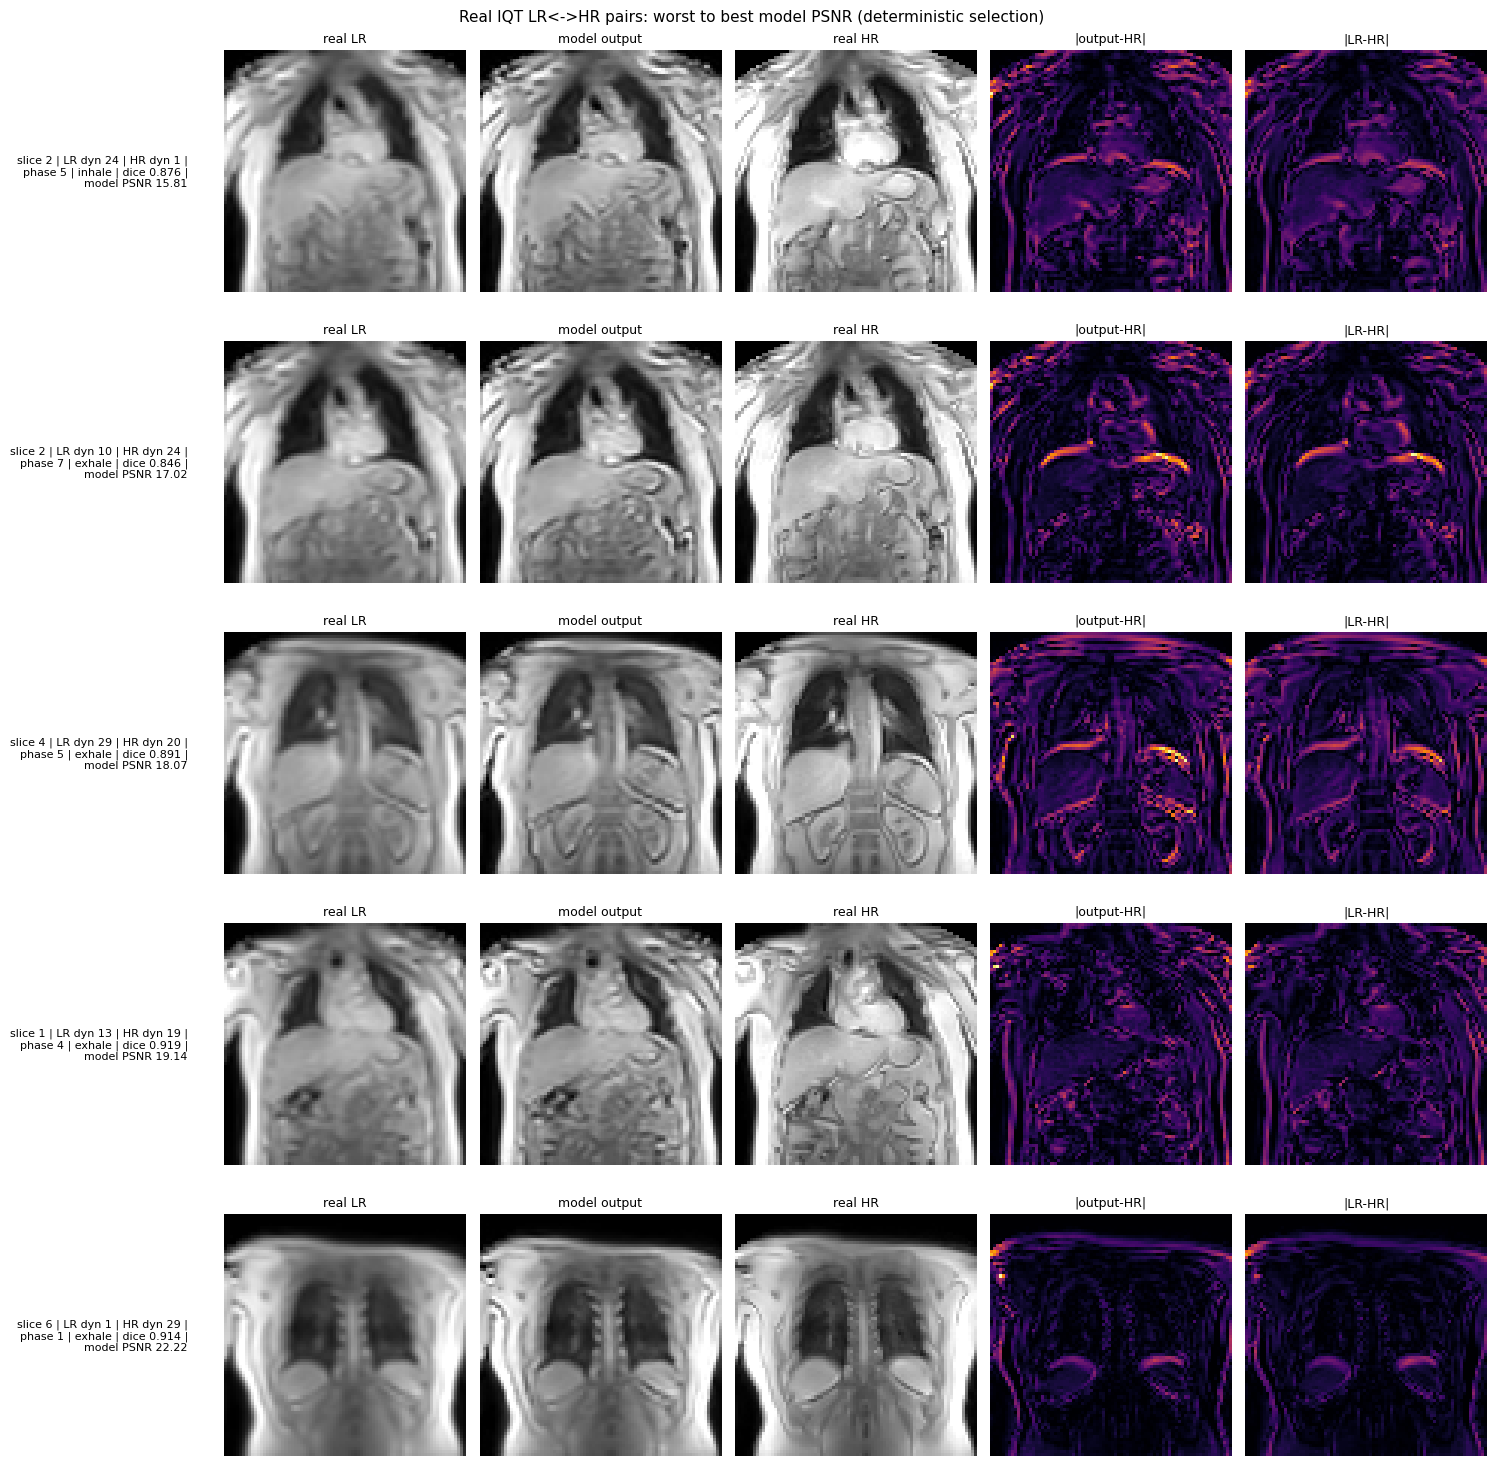

In [11]:
# --- qualitative real-data figures: real lr | model output | real hr | |output-hr|, plus
# |lr-hr| for the baseline comparison. deterministic selection spanning slices/phases/
# directions, including some of the WORSE-performing pairs, not only the best ---
sorted_by_psnr = per_pair_df.sort_values("model_psnr")
n = len(sorted_by_psnr)
pick_positions = sorted(set([0, max(0, n // 4), n // 2, min(n - 1, 3 * n // 4), n - 1]))  # worst -> best, deterministic
example_rows = sorted_by_psnr.iloc[pick_positions]

fig, axes = plt.subplots(len(example_rows), 5, figsize=(15, 3 * len(example_rows)))
if len(example_rows) == 1:
    axes = axes[None, :]

for row_ax, (_, row) in zip(axes, example_rows.iterrows()):
    s = row["slice"]
    match_mask = ((slice_inc == s) & (real_lr_dyn[inc] == row["lr_dynamic"]) & (real_hr_dyn[inc] == row["hr_dynamic"]))
    i = np.where(match_mask)[0][0]
    lo, hi = real_percentile_scale[int(s)]
    lr_norm = normalise(lr_inc[i], lo, hi)
    hr_norm = normalise(hr_inc[i], lo, hi)
    with torch.no_grad():
        lr_t = torch.from_numpy(lr_norm).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred_np = (lr_t + model(lr_t)).clamp(0.0, 1.0)[0, 0].cpu().numpy()

    vmax = max(lr_norm.max(), hr_norm.max(), pred_np.max())
    out_err = np.abs(pred_np - hr_norm)
    lr_err = np.abs(lr_norm - hr_norm)
    err_vmax = max(out_err.max(), lr_err.max())

    imgs = [lr_norm, pred_np, hr_norm, out_err, lr_err]
    titles = ["real LR", "model output", "real HR", "|output-HR|", "|LR-HR|"]
    for ax, img, title in zip(row_ax, imgs, titles):
        cmap = "gray" if title in ("real LR", "model output", "real HR") else "inferno"
        v = vmax if cmap == "gray" else err_vmax
        ax.imshow(img, cmap=cmap, vmin=0, vmax=v)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    row_ax[0].text(-0.15, 0.5, f"slice {row['slice']} | LR dyn {row['lr_dynamic']} | HR dyn {row['hr_dynamic']} |\n"
                                f"phase {row['phase_bin']:.0f} | {row['direction']} | dice {row['mean_dice']:.3f} |\n"
                                f"model PSNR {row['model_psnr']:.2f}",
                    transform=row_ax[0].transAxes, fontsize=8, ha="right", va="center")

fig.suptitle("Real IQT LR<->HR pairs: worst to best model PSNR (deterministic selection)", fontsize=11)
plt.tight_layout()
real_examples_path = OUTPUT_DIR / "test_real_pairs_qualitative_examples.png"
fig.savefig(real_examples_path, dpi=120, bbox_inches="tight")
print(f"saved: {real_examples_path}")
plt.show()


saved: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\test_real_pairs_mean_error_map.png


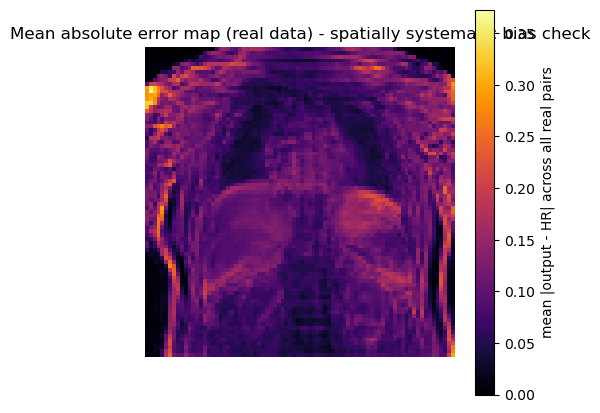


mean error map peak: 0.3731  mean: 0.0913
a spatially concentrated (not diffuse) peak here, in the same place across pairs, would indicate a systematic hallucination/bias rather than random reconstruction noise - inspect the figure directly rather than relying on this summary number alone.


In [12]:
# --- hallucination / fidelity inspection ---
# improved psnr/ssim on real data does not by itself prove the model's added detail is
# anatomically correct - it only means the output is numerically closer to the paired hr
# on average. the |output-hr| maps above are the direct evidence for whether the model
# introduces structure absent from the lr input and inconsistent with the hr reference;
# a systematic bias here (structure appearing in EVERY output at the same location,
# regardless of the specific lr content) would be a stronger red flag than a diffuse
# per-pixel error, since it would suggest a learned prior overriding the input rather
# than genuine recovery of hr detail.
out_err_maps = []
with torch.no_grad():
    for i in range(len(lr_inc)):
        lo, hi = real_percentile_scale[int(slice_inc[i])]
        lr_norm = normalise(lr_inc[i], lo, hi)
        hr_norm = normalise(hr_inc[i], lo, hi)
        lr_t = torch.from_numpy(lr_norm).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred_np = (lr_t + model(lr_t)).clamp(0.0, 1.0)[0, 0].cpu().numpy()
        out_err_maps.append(np.abs(pred_np - hr_norm))
mean_out_err_map = np.stack(out_err_maps).mean(axis=0)

plt.figure(figsize=(5, 5))
plt.imshow(mean_out_err_map, cmap="inferno")
plt.colorbar(label="mean |output - HR| across all real pairs")
plt.title("Mean absolute error map (real data) - spatially systematic bias check")
plt.axis("off")
mean_err_path = OUTPUT_DIR / "test_real_pairs_mean_error_map.png"
plt.savefig(mean_err_path, dpi=120, bbox_inches="tight")
print(f"saved: {mean_err_path}")
plt.show()

print(f"\nmean error map peak: {mean_out_err_map.max():.4f}  mean: {mean_out_err_map.mean():.4f}")
print("a spatially concentrated (not diffuse) peak here, in the same place across pairs, "
      "would indicate a systematic hallucination/bias rather than random reconstruction "
      "noise - inspect the figure directly rather than relying on this summary number alone.")


In [13]:
# --- final summary ---
print("=== test.ipynb summary (real acquired IQT data) ===")
print(f"checkpoint: {CHECKPOINT_PATH}")
print(f"candidate pairs: {n_candidate}  included: {n_included}  excluded: {n_excluded}")
print(f"\nreal LR baseline vs real HR:  L1={agg.loc['L1','Real LR baseline']:.4f}  "
      f"PSNR={agg.loc['PSNR','Real LR baseline']:.2f}  SSIM={agg.loc['SSIM','Real LR baseline']:.4f}")
print(f"model output    vs real HR:  L1={agg.loc['L1','Model output']:.4f}  "
      f"PSNR={agg.loc['PSNR','Model output']:.2f}  SSIM={agg.loc['SSIM','Model output']:.4f}")
print(f"difference (model - baseline): L1={agg.loc['L1','Difference']:+.4f}  "
      f"PSNR={agg.loc['PSNR','Difference']:+.2f}  SSIM={agg.loc['SSIM','Difference']:+.4f}")
print("\nthis is a result to report, not a target to tune against - the training "
      "pipeline stays frozen regardless of how this compares to the synthetic tv8 result.")


=== test.ipynb summary (real acquired IQT data) ===
checkpoint: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt
candidate pairs: 180  included: 180  excluded: 0

real LR baseline vs real HR:  L1=0.0876  PSNR=18.73  SSIM=0.6881
model output    vs real HR:  L1=0.0913  PSNR=18.16  SSIM=0.6748
difference (model - baseline): L1=+0.0036  PSNR=-0.57  SSIM=-0.0133

this is a result to report, not a target to tune against - the training pipeline stays frozen regardless of how this compares to the synthetic tv8 result.
